This notebook presents the work related to STA LTA processing of the waveforms for the physics involvement of the project in the data processing of the whole project.

In [40]:
import seisbench.data as sbd

dataset = sbd.STEAD()
print(len(dataset))

2026-03-13 16:39:08,645 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


1265657


The below code describes the meta data mathematical aspects/attributes

In [41]:
dataset.metadata["trace_p_arrival_sample"].describe()
dataset.metadata["trace_s_arrival_sample"].describe()

count    1.030231e+06
mean     1.335152e+03
std      6.054792e+02
min      1.900000e+02
25%      9.240000e+02
50%      1.207000e+03
75%      1.615000e+03
max      5.644000e+03
Name: trace_s_arrival_sample, dtype: float64

In [42]:
valid_eq = dataset.metadata[
    (dataset.metadata["trace_category"] == "earthquake_local") &
    (dataset.metadata["trace_p_arrival_sample"] < 3000) &
    (dataset.metadata["trace_s_arrival_sample"] < 3000)
]

print(len(valid_eq))

1004572


In [43]:
idx = valid_eq.index[0]
waveform = dataset.get_waveforms([idx])[:, :, :3000]

metadata = dataset.metadata.loc[idx]

print("P arrival:", metadata["trace_p_arrival_sample"])
print("S arrival:", metadata["trace_s_arrival_sample"])
print("Waveform shape:", waveform.shape)

P arrival: 700.0
S arrival: 1894.0
Waveform shape: (1, 3, 3000)


Main STA LTA function includes converting the descrete samples which are amplitudes of the waveform into something meanining full by having short term average which is for 50 samples and long term average which is for 500 samples.\\ This is done for having a localized peak detection of the waveforms which is particularly usefull for sensing/picking the P and S waves in the waveform.

Where as the global average which was used in the phase 1 of the project has taken the waveform as the whole which is 3000 samples with 100 Hz sampling rate therefore taken a sample of 30 seconds and checking weather that whole waveform contains an average above then a treshold which will detect any abnormally high seismic activity therefore detecting an Earthquake.



In [44]:
import numpy as np

def compute_sta_lta(waveform, sta=50, lta=500, eps=1e-8):
    
    # waveform shape: (3, 3000)
    z, n, e = waveform
    
    # compute signal energy
    energy = z**2 + n**2 + e**2
    
    # moving averages
    sta_vals = np.convolve(energy, np.ones(sta)/sta, mode="same")
    lta_vals = np.convolve(energy, np.ones(lta)/lta, mode="same")
    
    # STA/LTA ratio
    ratio = sta_vals / (lta_vals + eps)
    
    # normalize
    ratio = ratio / np.max(ratio)
    
    return ratio

After computing the STA and LTA we can obesrve that the value peaks at 1 which is where the method will think that there is a spike in the waveform.

But this peak doesnt exactly mean that the p wave or a S wave has occured in that place, as STA and LTA is an averaging technique, we can know that the activity has occured around that region which can be input to our model. This result will add as an extra input to our model which will say that there is an unusual activity around that area in the waveform therefore learinig the P wave arrival and S wave arrival.

In [45]:
wave = waveform[0]      # remove batch dimension
sta_lta = compute_sta_lta(wave)

print(sta_lta.shape)
print(np.min(sta_lta), np.max(sta_lta))

(3000,)
8.035788258480577e-05 1.0


The below graph will shows how the STA LTA technique has worked in extracting the peaks in the wavefom, but as we can see that there are many other points whrere there is abnormally high peaks in the waveform therefore showing that STA and LTA solely cant be used to detect/pick seismic activity


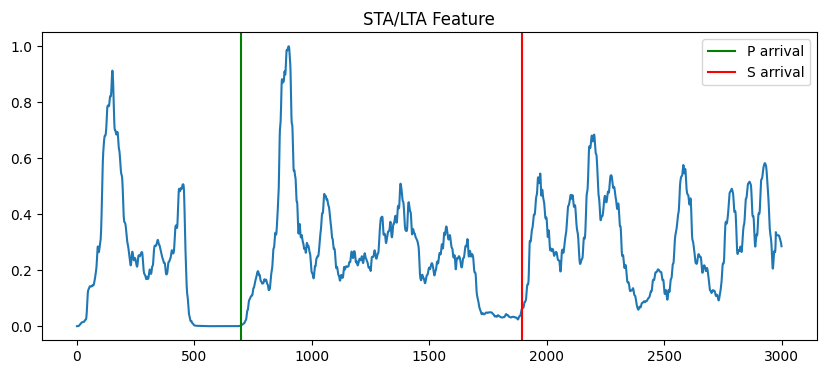

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(sta_lta)
plt.axvline(700, color="g", label="P arrival")
plt.axvline(1894, color="r", label="S arrival")
plt.legend()
plt.title("STA/LTA Feature")
plt.show()

As to our model, having abnormally high peaks discretely will tend to degrade our model by having geadient learning probelms. therefore we need to smooth out the  discrete peaks, this is where normal distribution comes in, normal distribution is a bell shaped curve which can be learned by the model easily. Converting this STA LTA analysis into normal distribution will impact the model training and make it train easily.


In [47]:
def gaussian_pick(arrival, length=3000, sigma=15):

    t = np.arange(length)
    target = np.exp(-(t - arrival)**2 / (2 * sigma**2))

    return target

In [48]:
p_target = gaussian_pick(700)
s_target = gaussian_pick(1894)

print(p_target.shape, s_target.shape)

(3000,) (3000,)


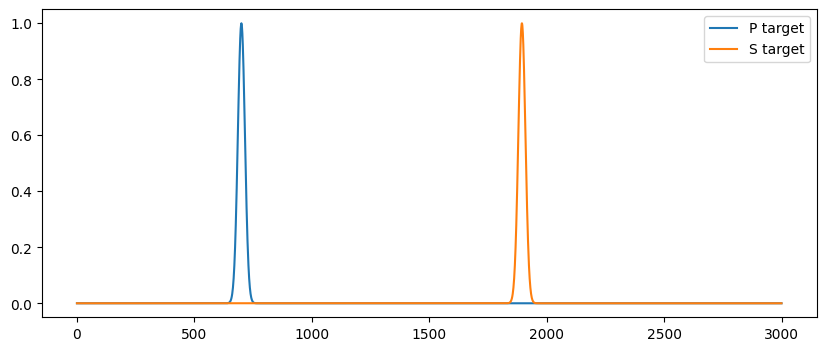

In [49]:
plt.figure(figsize=(10,4))
plt.plot(p_target,label="P target")
plt.plot(s_target,label="S target")
plt.legend()
plt.show()

In [50]:
p_target.max()
s_target.max()

np.float64(1.0)

Now we have the normalized distribution of the STA LTA which needs to be fed into our model architecture as an extra input.

In [51]:
import torch

model = torch.load("../res_models/backbone_models/final_model.pth", map_location="cpu")

print(model)

OrderedDict([('input_conv.weight', tensor([[[-0.3357],
         [-0.0016],
         [-0.5669]],

        [[ 0.0626],
         [ 0.5329],
         [ 0.0709]],

        [[ 0.0446],
         [ 0.2615],
         [ 0.0708]],

        [[-0.5927],
         [-0.2647],
         [ 0.0964]],

        [[ 0.1313],
         [ 0.3388],
         [ 0.5677]],

        [[-0.6548],
         [ 0.3640],
         [ 0.2254]],

        [[-0.1844],
         [-0.2381],
         [ 0.5108]],

        [[-0.6112],
         [ 0.2901],
         [-0.2809]],

        [[-0.1530],
         [-0.2135],
         [-0.3956]],

        [[ 0.1184],
         [ 0.5941],
         [ 0.3776]],

        [[ 0.4487],
         [ 0.1811],
         [-0.1956]],

        [[-0.5075],
         [ 0.2342],
         [ 0.0321]],

        [[-0.1978],
         [ 0.5519],
         [ 0.1088]],

        [[ 0.0973],
         [ 0.4034],
         [-0.3211]],

        [[-0.4503],
         [ 0.5577],
         [ 0.1942]],

        [[ 0.0443],
         [ 0.14

In [52]:
import torch

obj = torch.load("../res_models/backbone_models/final_model.pth", map_location="cpu")

print(type(obj))

<class 'collections.OrderedDict'>


In [53]:
state = torch.load("../res_models/backbone_models/checkpoint_epoch9.pth", map_location="cpu")

for k in state["model_state_dict"].keys():
    print(k)

input_conv.weight
input_conv.bias
blocks.0.conv1.conv.weight
blocks.0.conv1.conv.bias
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.conv2.conv.weight
blocks.0.conv2.conv.bias
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.1.conv1.conv.weight
blocks.1.conv1.conv.bias
blocks.1.norm1.weight
blocks.1.norm1.bias
blocks.1.conv2.conv.weight
blocks.1.conv2.conv.bias
blocks.1.norm2.weight
blocks.1.norm2.bias
blocks.2.conv1.conv.weight
blocks.2.conv1.conv.bias
blocks.2.norm1.weight
blocks.2.norm1.bias
blocks.2.conv2.conv.weight
blocks.2.conv2.conv.bias
blocks.2.norm2.weight
blocks.2.norm2.bias
blocks.3.conv1.conv.weight
blocks.3.conv1.conv.bias
blocks.3.norm1.weight
blocks.3.norm1.bias
blocks.3.conv2.conv.weight
blocks.3.conv2.conv.bias
blocks.3.norm2.weight
blocks.3.norm2.bias
blocks.4.conv1.conv.weight
blocks.4.conv1.conv.bias
blocks.4.norm1.weight
blocks.4.norm1.bias
blocks.4.conv2.conv.weight
blocks.4.conv2.conv.bias
blocks.4.norm2.weight
blocks.4.norm2.bias
blocks.5.conv1.conv.weight

In [54]:
from models import ResidualCausalTCN

In [55]:
model = ResidualCausalTCN()

checkpoint = torch.load("../res_models/backbone_models/checkpoint_epoch9.pth", map_location="cpu")

model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [56]:
x = torch.randn(1,3,3000)

y = model(x)

print(y.shape)

torch.Size([1, 1])


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [58]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import seisbench.data as sbd
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import time

In [60]:
from models import ResidualBlock, CausalConv1d

In [61]:
class Phase2MultiTaskTCN(nn.Module):

    def __init__(self):
        super().__init__()

        # Input projection (4 channels now: Z, N, E, STA/LTA)
        self.input_conv = nn.Conv1d(4, 32, kernel_size=1)

        dilations = [1,2,4,8,16,32,64,128]

        self.blocks = nn.Sequential(
            *[ResidualBlock(32,5,d) for d in dilations]
        )

        # Detection head (same idea as Phase-1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32,1)

        # Phase heads
        self.p_head = nn.Conv1d(32,1,kernel_size=1)
        self.s_head = nn.Conv1d(32,1,kernel_size=1)

    def forward(self,x):

        x = self.input_conv(x)
        features = self.blocks(x)          # (B,32,3000)

        # Detection branch
        det = self.pool(features).squeeze(-1)
        det = self.fc(det)

        # Phase picking branches
        p_map = torch.sigmoid(self.p_head(features)).squeeze(1)
        s_map = torch.sigmoid(self.s_head(features)).squeeze(1)

        return det, p_map, s_map